In [28]:
# Ignore all other GPUs except this one
!export CUDA_VISIBLE_DEVICES=1

In [29]:
import torch
from torch import nn
from torch import optim
from torch.autograd import grad
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.jit as jit

import numpy as np
import matplotlib.pyplot as plt

import os
import time
import pickle
import tqdm
import random
import typing
import itertools
from typing import Union
from datetime import datetime

plt.style.use('seaborn-v0_8-poster')
# import LBFGS
# from LBFGS import FullBatchLBFGS

Some Utility Functions (Not Physics Related)

In [30]:
def set_seed(seed: int = 42) -> None: #meaning of life 

    """
    Function to set the PRNG seed of the sampling, NN initialization, etc.
    Used for reproducibility.

    Inputs: 
    - seed (int): PRNG seed. Default: 42 (Meaning of Life, the Universe, and Everything)

    Outputs:
    None
    """

    if type(seed) != int:
        raise Exception("Input seed must be an integer.")

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def np_to_tensor(arr: np.ndarray, reshape: bool = False, dims: tuple = (-1,1), device: torch.device = torch.device("cpu"), dtype: torch.dtype = torch.float32, requires_grad: bool = False) -> torch.Tensor:

    """
    Function to convert NumPy array to Pytorch tensor. Optionally, the tensor can be reshaped,
    which is specified with the boolean flag 'reshape'. If 'reshape' is True, the tensor is reshaped
    to have dimension 'dims', which should be passed as a tuple.

    Inputs:
    - arr (array): NumPy array to be converted to a PyTorch tensor.
    - reshape (bool): boolean flag indicating whether or not to reshape the array. Default: False
    - dims (tuple): tuple indicating what shape to reshape the array to, if desired. Default: (-1,1)
    - device (torch.device): indicates whether resulting tensor will be on CPU or GPU, and if GPU, which one. Default: torch.device("cpu")
    - dtype (torch.dtype): indicates what dtype the elements of the resulting tensor will have. Default: torch.float32
    - requires_grad (bool): boolean flag indicating whether or not operations on the resulting tensor will be recorded with autograd. Default: False

    Outputs:
    - PyTorch tensor corresponding to the input 'arr'.
    """

    if reshape:
        return torch.tensor(arr.reshape(dims), dtype=dtype, requires_grad=requires_grad, device=device)
    else:
        return torch.tensor(arr, dtype=dtype, requires_grad=requires_grad, device=device)


def tensor_to_np(tensor: torch.Tensor, reshape: bool = False, dims: tuple = (-1,1)) -> np.ndarray:

    """
    Function to convert PyTorch tensor to NumPy array. Optionally, the array can be reshaped,
    which is specified with the boolean flag 'reshape'. If 'reshape' is True, the array is reshaped
    to have dimension 'dims', which should be passed as a tuple.

    Inputs:
    - tensor (tensor): PyTorch tensor to be converted to a NumPy array.
    - reshape (bool): boolean flag indicating whether or not to reshape the array.
    - dims (tuple): tuple indicating what shape to reshape the array to, if desired.

    Outputs:
    - NumPy array corresponding to the input 'tensor'.
    """

    if reshape:
        return tensor.reshape(dims).detach().cpu().numpy()
    else:
        return tensor.detach().cpu().numpy()

def get_lr(optimizer) -> float:
    
    """
    Function gives the current (global) learning rate of the passed optimizer.

    Inputs:
    - optimizer (instance of torch.optim class)

    Outputs:
    - (Global) learning rate associated with 'optimizer'.
    """
    
    return optimizer.param_groups[0]['lr']

Here we are defining our quantities from analytical theory. \
We will assume all perturbed quantities $(E,B,\vec{v_e}, n_e)$ vary ~ $e^{i(kx-\omega t)}$ 

Dispersion relation is as follows: $N^2 = \frac{K^2 - D^2}{K}$\
where $N^2 = \frac{c^2k^2}{\omega^2}, K = 1- \frac{\omega_{pe}}{\omega^2 - \omega_{ce}^2}, D = \frac{\omega_{ce}}{\omega}\frac{\omega_{pe}}{\omega^2 - \omega_{ce}^2}$

In [31]:
#Define Physical Parameters

vth = 0.1 #thermal velocity in units of c (c=1)

#frequencies in units of omega_pe
omega_ce = 2.0 #electron cyclotron frequency
omega = 2.5 #For our choice of omega_ce, the cutoff omega_R/omega_ce ~2.44, so choose to set omega = 2.5
omega_pe = 1.0 #plasma frequency, normalized to itself

E_amp = 1.0 #Amplitude of Electric Field in units of omega_pe*(mc/e)

#calculate k from dispersion relation
def x_wave_dispersion(omega, omega_ce, omega_pe):
    """
    Function to calculate the wave number k and the normalized wave number k_lambda_D.
    
    Inputs:
    -omega(float):  wave frequency normalized to plasma frequency (omega_pe)
    -omega_ce(float): electron cyclotron frequency normalized to plasma frequency (omega_pe)
    -omega_pe(float): plasma frequency normalized to itself (usually set to 1)
    
    Outputs:
    -k(float): wave number in units of omega_pe/c
    -k_lambda_D(float): Unitless product k*lambda_D, where lambda_D is the Debye length.
    """
    
    c=1 #just for clarity
    factor = omega_pe**2/ (omega**2 - omega_ce**2)
    K = 1-factor
    D = (omega_ce/omega) * factor
    csq_ksq = omega**2 * (K**2 - D**2)/K
    
    k = np.sqrt(csq_ksq/c)
    k_lambda_D = k*vth
    
    return k, k_lambda_D

In [32]:
k, k_lambda_D = x_wave_dispersion(omega, omega_ce, omega_pe)
print(f"k = {k:.3f}, k*lambda_D = {k_lambda_D:.3f}")

k = 1.432, k*lambda_D = 0.143


Here, we generate our data from analytical theory. 

In [33]:
def check_size_eq(lst):
    """Check if all lists in lst have the same size."""
    return not any(len(lst[0])!= len(i) for i in lst)

def phase_factor(delta):
    """Calculate the phase factor for the wave solution."""
    return np.exp(1j*delta)

def analytical_solution(x, t, omega, k, E_amp, delta):
    
    E_amp *= phase_factor(delta)
    
    c=1 #just for clarity
    factor_dielectric = omega_pe**2/ (omega**2 - omega_ce**2)
    factor_freq = omega_ce/(omega_pe*omega)
    K = 1-factor_dielectric
    D = (omega_ce/omega) * factor_dielectric
    Nsq = (c**2 * k**2)/omega**2
    
    Ex = E_amp * np.exp(1j*(k*x - omega*t)) #longtiduninal electrostatic part (vector)
    Ey = Ex * 1j*D/(K-Nsq) #transverse electromagnetic part
    Bz = k*Ey*t #(vector)
    Vx = (1/omega)*(-1j*Ex - factor_freq*Ey)*(1/(1-factor_freq)) #(vector)
    Vy = (1/omega)*(-1j*Ey - factor_freq*Ex)*(1/(1-factor_freq))
    N = (k/omega) * Vx #(scaler) N' = N/N0
    phi = (1j/k)*Ex #(scaler) phi measurements
    Bdot = -1j*omega*Bz #(vector) Bdot measurements (z direction)
    P = vth**2 * (N**3) #(scaler) electron pressure
     
    return Ex, Ey, Bz, Vx, Vy, N, P, phi, Bdot,


def generate_data(xmin, xmax, tmin, tmax, nx, nt, omega_list, E_amp_list, delta_list):

    if not check_size_eq([omega_list, E_amp_list, delta_list]):
        raise Exception("Parameter lists are not the same size!")

    x = np.linspace(xmin, xmax, nx)
    t = np.linspace(tmin, tmax, nt)

    x_arr, t_arr = np.meshgrid(x,t)

    Ex = np.zeros_like(x_arr, dtype=np.complex128)
    Ey = np.zeros_like(x_arr, dtype=np.complex128)
    Bz = np.zeros_like(x_arr, dtype=np.complex128)
    Vx = np.zeros_like(x_arr, dtype=np.complex128)
    Vy = np.zeros_like(x_arr, dtype=np.complex128)
    N = np.zeros_like(x_arr, dtype=np.complex128)
    phi = np.zeros_like(x_arr, dtype=np.complex128)
    Bdot = np.zeros_like(x_arr, dtype=np.complex128)
    P = np.zeros_like(x_arr, dtype=np.complex128)

    for i in range(len(omega_list)):
        temp_Ex, temp_Ey, temp_Bz, temp_Vx, temp_Vy, temp_N, temp_P, temp_phi, temp_Bdot, = analytical_solution(x_arr, t_arr, omega_list[i], \
                                                               x_wave_dispersion(omega_list[i], omega_ce, omega_pe)[0], \
                                                               E_amp_list[i], delta_list[i])
        Ex += temp_Ex
        Ey += temp_Ey
        Bz += temp_Bz
        Vx += temp_Vx
        Vy += temp_Vy
        N += temp_N
        phi += temp_phi
        Bdot += temp_Bdot
        P += temp_P

    return x_arr.flatten(), t_arr.flatten(), np.real(Ex).flatten(),np.real(Ey).flatten(), \
            np.real(Bz).flatten(), np.real(Vx).flatten(), np.real(Vy).flatten(), \
            np.real(N).flatten(), np.real(P).flatten(), np.real(phi).flatten(), np.real(Bdot).flatten()


def sparse_measurements(x, t, phi, Bdot, num_samples):

    indices = np.random.choice(x.shape[0], num_samples, replace=False)

    return x[indices], t[indices], phi[indices], Bdot[indices]


def collocation_points(xmin, xmax, tmin, tmax, Nx, Nt, L, tau):

    x = np.linspace(xmin, xmax, Nx)
    t = np.linspace(tmin, tmax, Nt)

    x_coll, t_coll = np.meshgrid(x, t)

    dx = x[1] - x[0]
    dt = t[1] - t[0]

    return x_coll.flatten(), t_coll.flatten(), dx, dt

In [34]:
omega_list = [omega]
E_amp_list = [E_amp]  # Amplitude of the electric field
delta_list = [0.0]  # Phase factor for the wave solution

lamda = 2 * np.pi / k  # Wavelength
T = (2 * np.pi) / omega  # Period of the wave
xmin, xmax = 0, 3*lamda
tmin, tmax = 0, 3*T

L = xmax - xmin  # Length of the domain
tau = tmax - tmin  # Time duration of the wave
Nt = 2000 # Number of time points
Nx = 2000 # Number of spatial points
Nt_coll = 200 
Nx_coll = 200
dt = T/float(Nt)
dx = L/float(Nx)

t_arr = np.linspace(tmin, tmax, Nt)
x_arr = np.linspace(xmin, xmax, Nx)

print(f"k = {k:.4e}")
print(f"k lambda_debye = {k_lambda_D:.4e}")
print(f"L = {L:.3e} [c / omega_pe]")
print(f"T = {T:.3e} [1 / omega_pe]")
print(f"dx = {dx:.3e} [c / omega_pe]")
print(f"dt = {dt:.3e} [1 / omega_pe]")

X_flat, T_flat, Ex_flat, Ey_flat, Bz_flat, Vx_flat, Vy_flat,  N_flat, P_flat, phi_flat, Bdot_flat = generate_data(
xmin, xmax, tmin, tmax, Nx, Nt, omega_list, E_amp_list, delta_list)

x_sparse, t_sparse, phi_sparse, Bdot_sparse = sparse_measurements(X_flat, T_flat, phi_flat, Bdot_flat, num_samples=200)

x_coll, t_coll, dx, dt = collocation_points(xmin, xmax, tmin, tmax, Nx_coll, Nt_coll, L, tau)

k = 1.4318e+00
k lambda_debye = 1.4318e-01
L = 1.317e+01 [c / omega_pe]
T = 2.513e+00 [1 / omega_pe]
dx = 6.583e-03 [c / omega_pe]
dt = 1.257e-03 [1 / omega_pe]


Here we have our "Ground Truth" Values \
We are more interested in $\nabla P_{e}$, so we will take the derivative along the electrostatic part.

In [35]:
def derivative_x(f, dx):

    f_x = np.zeros_like(f)

    f_x[:,1:-1] = (0.5*f[:,2:] - 0.5*f[:,0:-2]) / dx             # 2nd order accurate central difference stencil for interior points
    f_x[:,0] = (-1.5*f[:,0] + 2.0*f[:,1] - 0.5*f[:,2]) / dx      # 2nd order accurate forward difference stencil for x_0 edge
    f_x[:,-1] = (0.5*f[:,-3] - 2.0*f[:,-2] + 1.5*f[:,-1]) / dx   # 2nd order accurate backward difference stencil for x_f edge

    return f_x

def derivative_t(f, dt):

    f_t = np.zeros_like(f)

    f_t[:,1:-1] = (0.5*f[:,2:] - 0.5*f[:,0:-2]) / dt             # 2nd order accurate central difference stencil for interior points
    f_t[:,0] = (-1.5*f[:,0] + 2.0*f[:,1] - 0.5*f[:,2]) / dt      # 2nd order accurate forward difference stencil for t_0 edge
    f_t[:,-1] = (0.5*f[:,-3] - 2.0*f[:,-2] + 1.5*f[:,-1]) / dt   # 2nd order accurate backward difference stencil for t_f edge

    return f_t

In [36]:
#Ground Truth Values
Ex_GT = Ex_flat.reshape(Nt, Nx)
Ey_GT = Ey_flat.reshape(Nt, Nx)
Bz_GT = Bz_flat.reshape(Nt, Nx)
Vx_GT = Vx_flat.reshape(Nt, Nx)
Vy_GT = Vy_flat.reshape(Nt, Nx)
P_GT = P_flat.reshape(Nt, Nx)
N_GT = N_flat.reshape(Nt, Nx)
P_x_GT = derivative_x(P_GT, dx)
phi_GT = phi_flat.reshape(Nt, Nx)
Bdot_GT = Bdot_flat.reshape(Nt, Nx)



<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1136671/359391598.py:9: SyntaxWarning: invalid escape sequence '\p'
  f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$',
/tmp/ipykernel_1136671/359391598.py:10: SyntaxWarning: invalid escape sequence '\d'
  f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$']
/tmp/ipykernel_1136671/359391598.py:24: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')
/tmp/ipykernel_1136671/359391598.py:28: SyntaxWarning: invalid escape sequence '\p'
  if f'$\phi [\\f

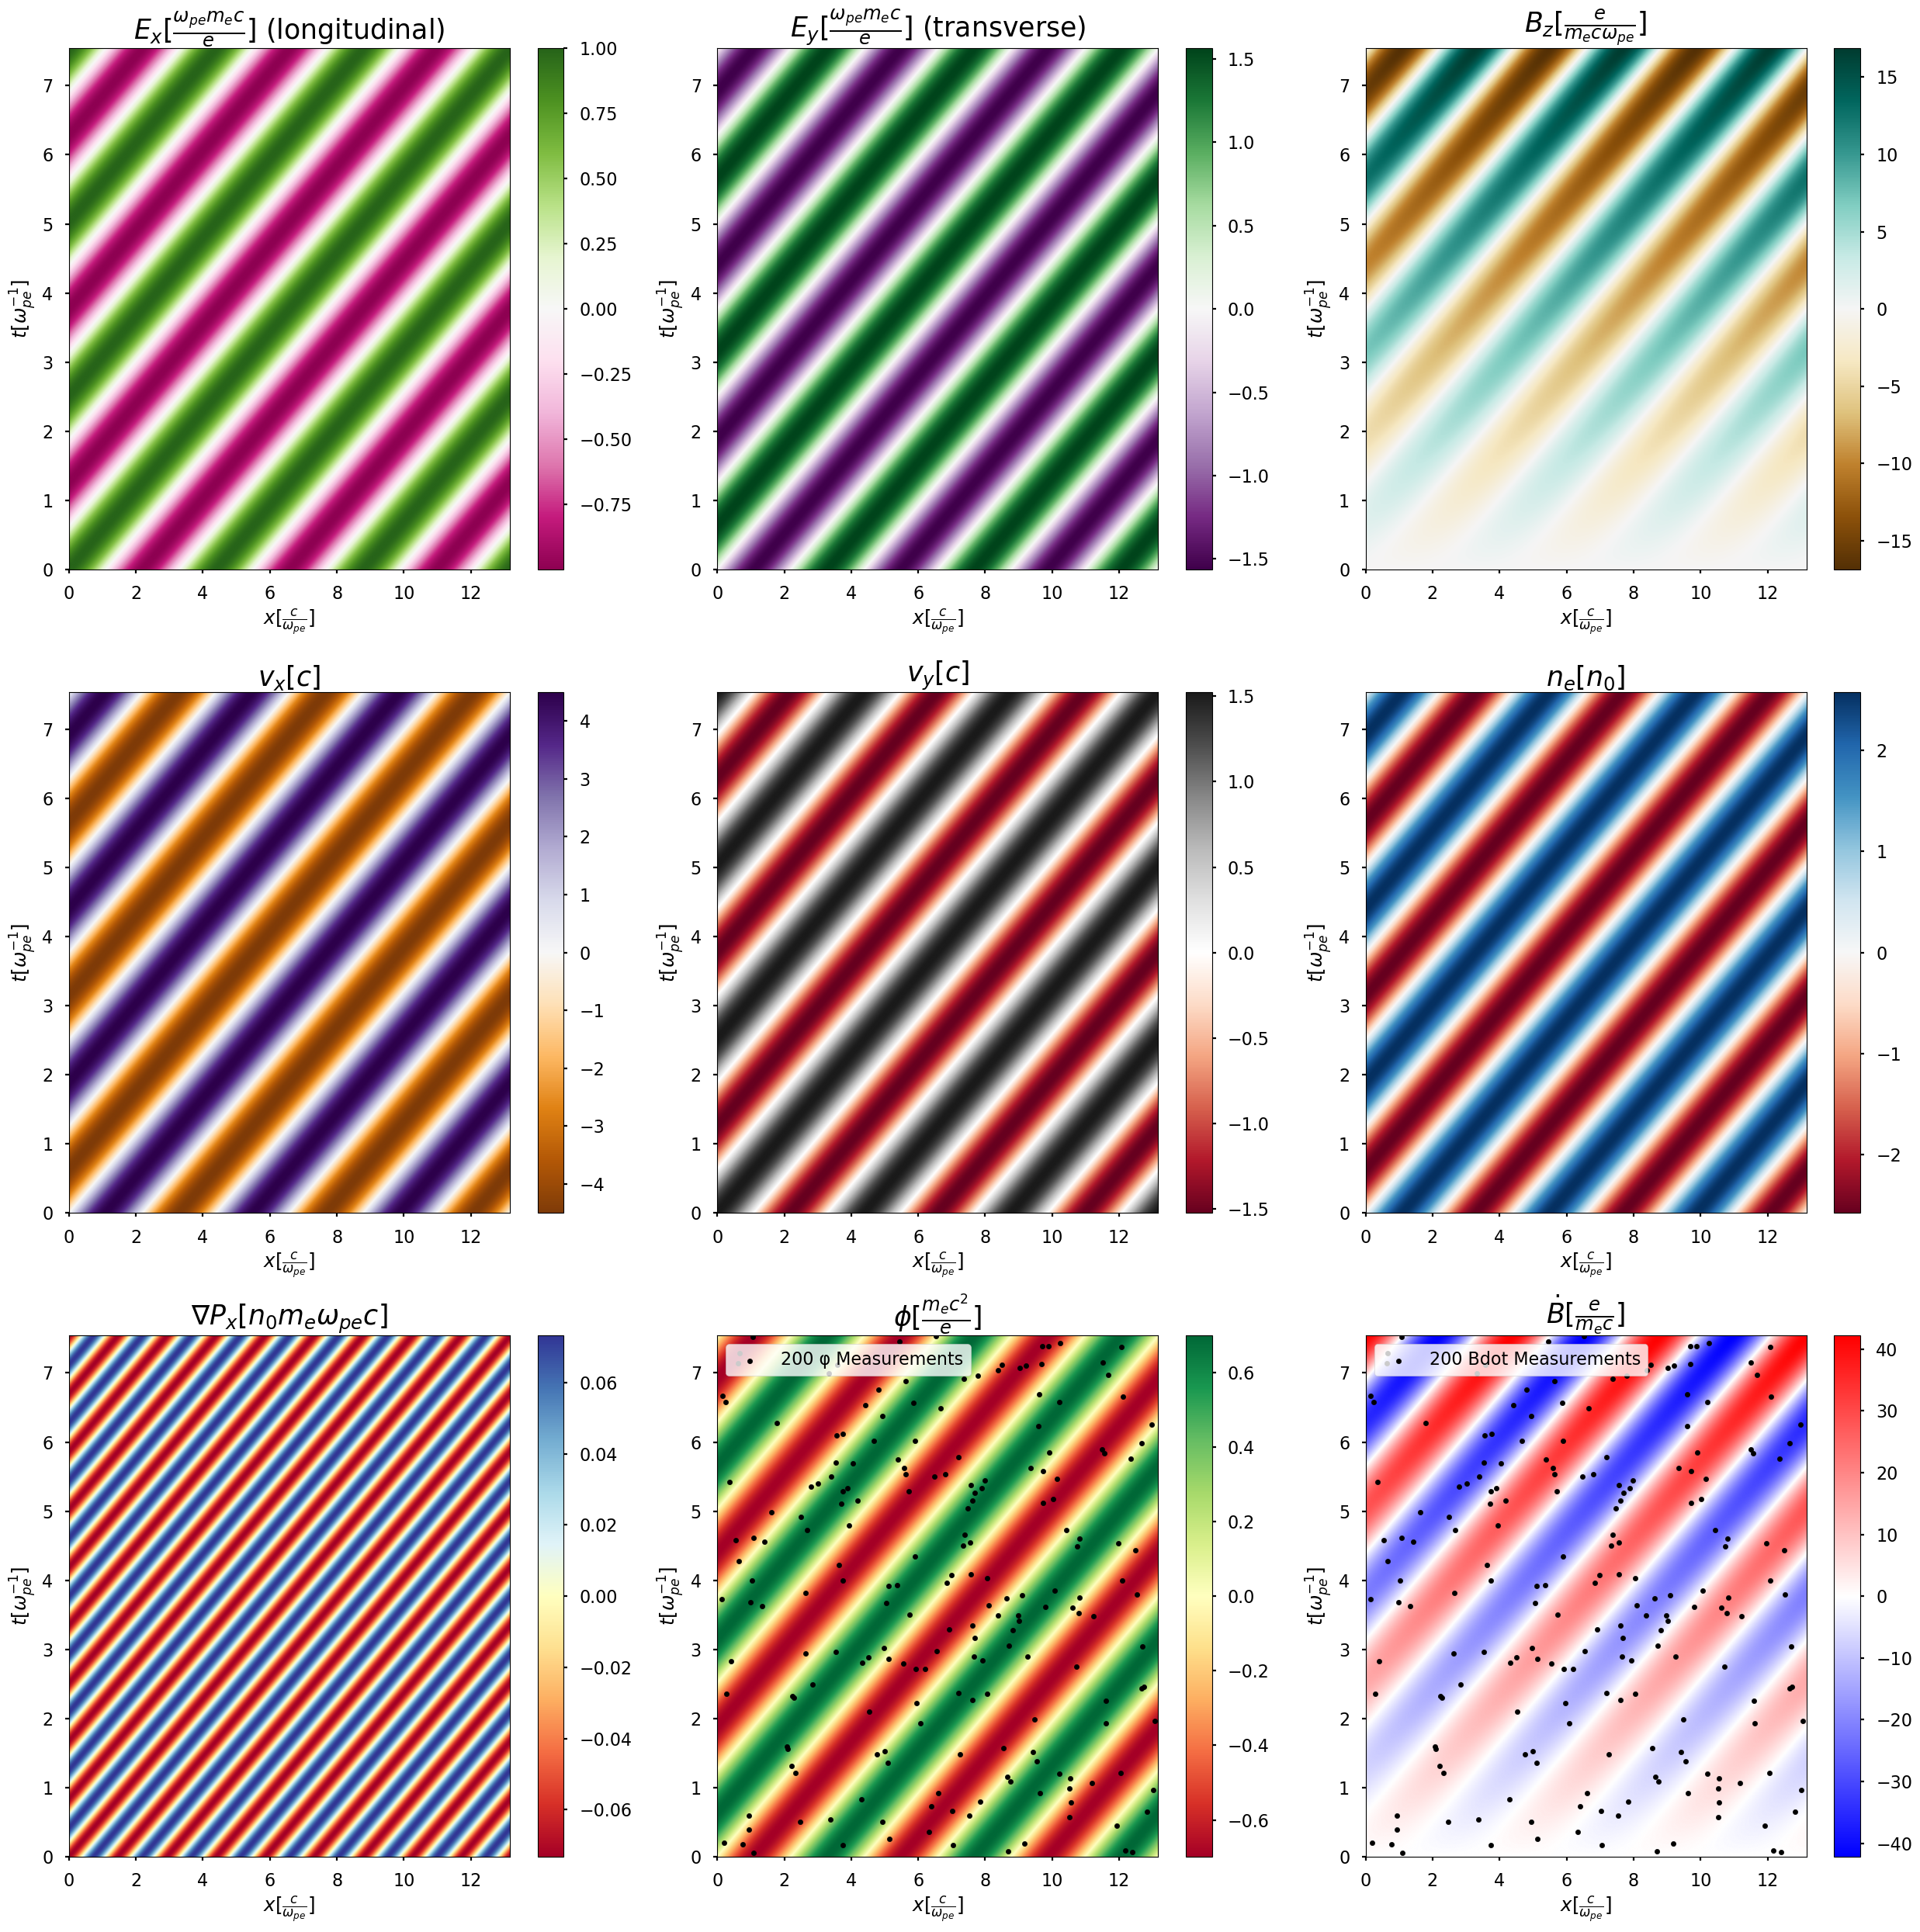

<Figure size 1280x880 with 0 Axes>

In [37]:
def plot_analytical():
    """Plot the analytical solution."""
    titles = [f'$E_x [\\frac{{\\omega_{{pe}}m_{{e}}c}}{{e}}]$ (longitudinal)', 
              f'$E_y [\\frac{{\\omega_{{pe}}m_{{e}}c}}{{e}}]$ (transverse)', 
              f'$B_z [\\frac{{e}}{{m_{{e}}c\\omega_{{pe}}}}]$',
              f'$v_x [c]$', f'$v_y [c]$', 
             f'$n_e [n_0]$', 
             f'$\\nabla P_x [n_0m_e\\omega_{{pe}}c]$',
             f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$', 
             f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$']
    extent = [xmin, xmax, tmin, tmax]
    
    fig, axes = plt.subplots(3, 3, figsize=(25, 25))
    quantities = [Ex_GT, Ey_GT, Bz_GT, 
                  Vx_GT, Vy_GT, N_GT, 
                  P_x_GT, phi_GT, Bdot_GT]
    colors = ['PiYG', 'PRGn', 'BrBG',
              'PuOr', 'RdGy', 'RdBu',
              'RdYlBu', 'RdYlGn', 'bwr']
                      
    for ax, quantity, title, color in zip(axes.flatten(), quantities, titles, colors):
        im = ax.imshow(quantity, aspect='auto', extent=extent, origin='lower', cmap=color)
        ax.set_title(title, fontsize = 25)
        ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')
        ax.set_ylabel('$t [\\omega_{{pe}}^{{-1}}]$')
        fig.colorbar(im, ax=ax)
        
        if f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$' in title:
            ax.scatter(x_sparse, t_sparse, c='black', s=20, label=f'200 φ Measurements', alpha=1.)
            ax.legend()
        if f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$' in title:
            ax.scatter(x_sparse, t_sparse, c='black', s=20, label=f'200 Bdot Measurements', alpha=1.)
            ax.legend()
            
    
    plt.tight_layout()
    plt.show()
    plt.suptitle("Ground Truth")
    
plot_analytical()


<>:56: SyntaxWarning: invalid escape sequence '\o'
<>:56: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1136671/129827966.py:56: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')


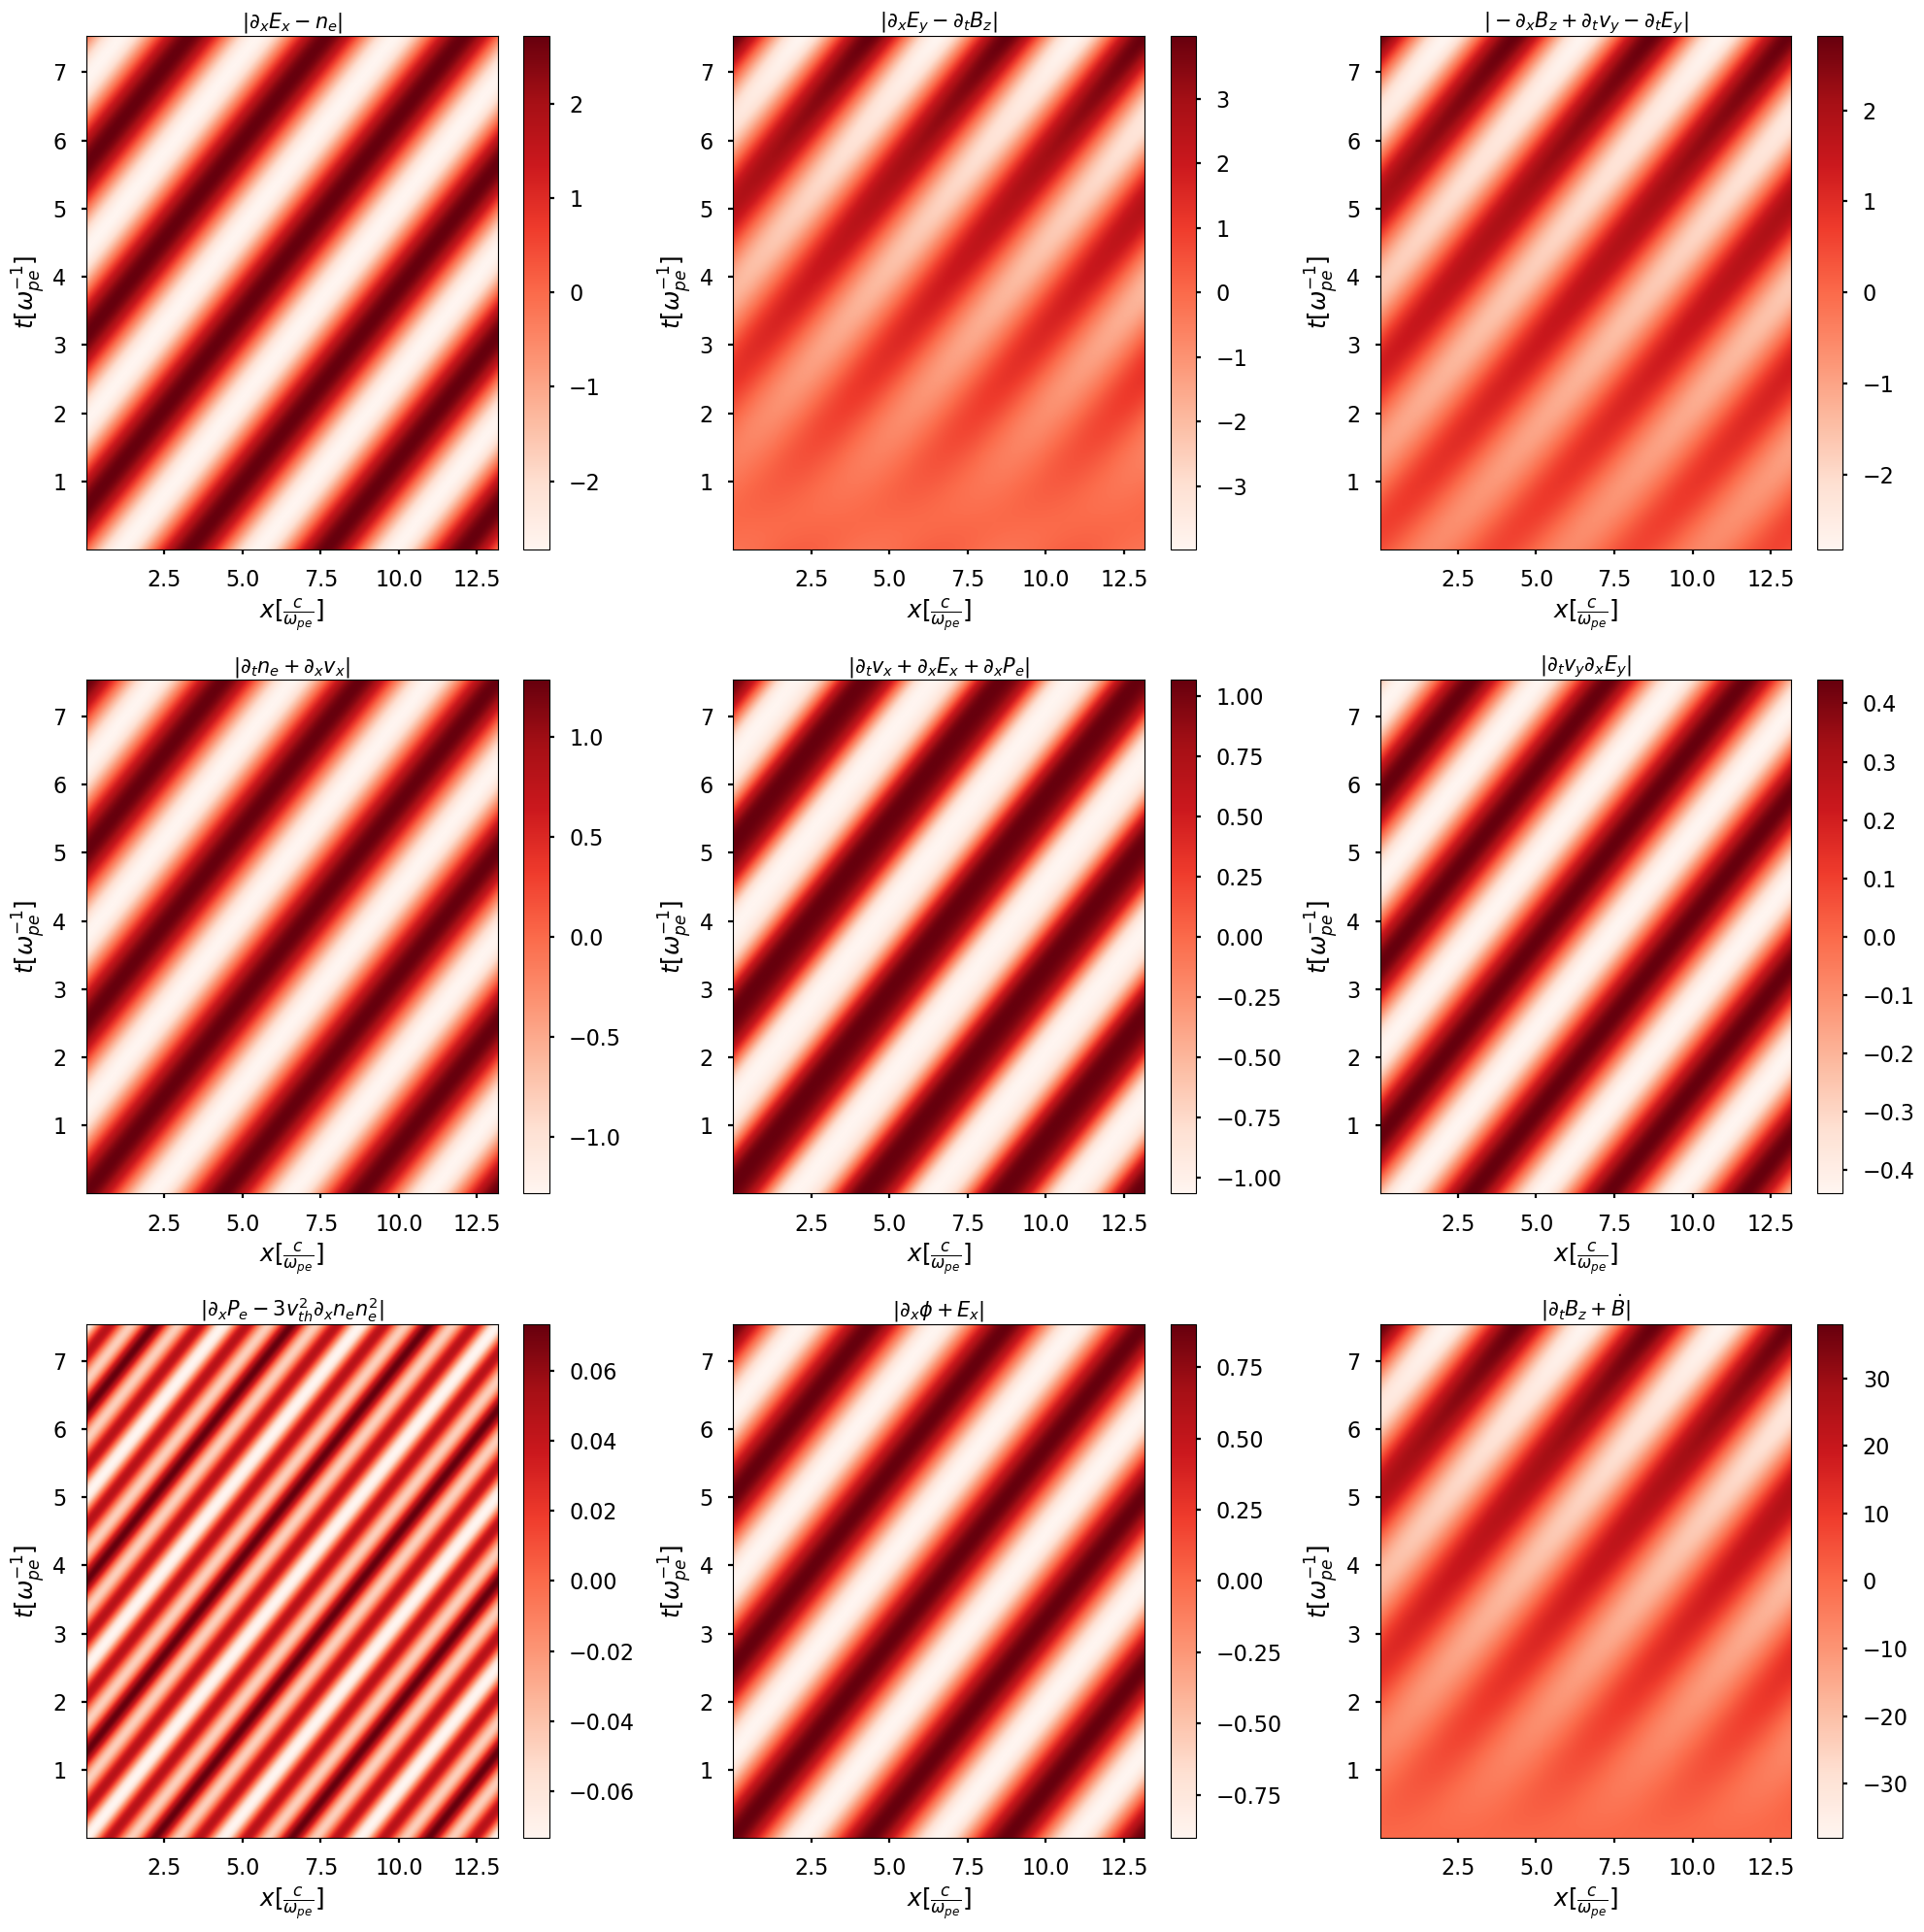

In [38]:
P_x = P_x_GT
N = N_GT
Ex = Ex_GT
Bdot = Bdot_GT

Ex_x = derivative_x(Ex_GT, dx)
Ey_x = derivative_x(Ey_GT, dx)
Bz_x = derivative_x(Bz_GT, dx)
curl_E = Ey_x
curl_B = -Bz_x

Ex_t = derivative_t(Ex_GT, dt)
Ey_t = derivative_t(Ey_GT, dt)
Bz_t = derivative_t(Bz_GT, dt)

N_t = derivative_t(N_GT, dt)
N_x = derivative_x(N_GT, dx)

Vx_x = derivative_x(Vx_GT, dx)
Vx_t = derivative_t(Vx_GT, dt)
Vy_t = derivative_t(Vy_GT, dt)

Phi_x = derivative_x(phi_GT, dx)

gauss_x = Ex_x - N_GT #1
faraday_x = curl_E - Bz_t #2
ampere_y = curl_B + Vy_t - Ey_t #3
continuity = N_t + Vx_x #4
momentum_x = Vx_t + Ex_x + P_x #5
momentum_y = Vy_t + Ey_x #6
adiabatic = P_x - 3*(vth**2)*N_x*(N**2) #7
electrostatic = Phi_x + Ex #8
dbdt = Bz_t + Bdot #9



def plot_constraints():
    "Plots the constraints in their current form."
    titles = [f'$|\\partial_x E_x - n_e|$', 
              f'$|\\partial_x E_y - \\partial_t B_z|$', 
              f'$|-\\partial_x B_z + \\partial_t v_y - \\partial_t E_y|$',
              f'$|\\partial_t n_e + \\partial_x v_x|$', 
              f'$|\\partial_t v_x + \\partial_x E_x + \\partial_x P_e|$', 
              f'$|\\partial_t v_y \\partial_x E_y|$', 
              f'$|\\partial_x P_e - 3 v_{{th}}^{{2}} \\partial_x n_e n_e^{{2}}|$',
              f'$|\\partial_x \\phi + E_x|$', 
              f'$|\\partial_t B_z + \\dot{{B}}|$']
    
    ext = [x_arr[1], x_arr[-2], t_arr[1], t_arr[-2]]
    constraints = [gauss_x, faraday_x, ampere_y, continuity, momentum_x, momentum_y, adiabatic, electrostatic, dbdt]
    fig, axes = plt.subplots(3, 3, figsize=(20, 20))
    
    for ax, constraint, title in zip(axes.flatten(), constraints, titles):
        im = ax.imshow(constraint, aspect='auto', extent=ext, origin='lower', cmap='Reds')
        ax.set_title(title, fontsize = 15)
        ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')
        ax.set_ylabel('$t [\\omega_{{pe}}^{{-1}}]$')
        fig.colorbar(im, ax=ax)
    
    plt.tight_layout()
    plt.show()
    
plot_constraints()
    


In [ ]:
# Helper functions for initialization of network parameters

def xavier_init_weights(network: nn.Module) -> nn.Module:
    with torch.no_grad():
        print("Initializing NN with glorot initialization...\n")
        for m in network:
            if hasattr(m, 'weight'):
                nn.init.xavier_normal_(m.weight)
                m.bias.data.fill_(0.0)

    return network

def kaiming_init_weights(network: nn.Module) -> nn.Module:
    with torch.no_grad():
        print("Initializing NN with he initialization...\n")
        for m in network:
            if hasattr(m, 'weight'):
                nn.init.kaiming_normal_(m.weight)
                m.bias.data.fill_(0.0)

    return network

# Helper function for initialization of activation function

def init_param(w0: float, device: torch.device, adaptive: bool) -> nn.Parameter:
    return nn.Parameter(torch.tensor(w0, dtype=torch.float32, requires_grad=adaptive, device=device))

# Helper function for Fourier Feature embedding

def encode_input(inp: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    input_proj = (2.0*torch.pi*inp) @ B.t()
    return torch.cat([torch.sin(input_proj), torch.cos(input_proj)], dim=-1)

# Activation function definitions

class Sin(nn.Module):

    def __init__(self, device: torch.device, w0: float = 1., adaptive: bool = False) -> None:
        super(Sin, self).__init__()
        self.w0 = init_param(w0, device, adaptive)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sin(self.w0 * x)

class Tanh(nn.Module):

    def __init__(self, device: torch.device, w0: float = 1., adaptive: bool = False) -> None:
        super(Tanh, self).__init__()
        self.w0 = init_param(w0, device, adaptive)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.tanh(self.w0 * x)

class Swish(nn.Module):

    def __init__(self, device: torch.device, w0: float = 1., adaptive: bool = False) -> None: 
        super(Swish, self).__init__()
        self.w0 = init_param(w0, device, adaptive)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * torch.sigmoid(self.w0 * x)

#Actual construction of the MLP class
class MLP(nn.Module):
    
    def __init__(self, extent: np.ndarray, device: torch.device, num_hidden_layers: int = 3, hidden_size: int = 50, activation: str = 'tanh', adaptive_af: bool = False, init: Union[None, str] = None, input_encoding: bool = False, sigma: float = 1.0, single_output: bool = False) -> None:
        
        super(MLP, self).__init__()
        
        self.tmin = torch.tensor(extent[0], dtype=torch.float32, device=device, requires_grad=False)
        self.tmax = torch.tensor(extent[1], dtype=torch.float32, device=device, requires_grad=False)
        self.xmin = torch.tensor(extent[2], dtype=torch.float32, device=device, requires_grad=False)
        self.xmax = torch.tensor(extent[3], dtype=torch.float32, device=device, requires_grad=False)
        
        self.num_hidden_layers = num_hidden_layers
        self.hidden_size = hidden_size
        self.input_size = 2  # spatiotemporal input (x, t)
        self.elapsed_iterations = 0
        
        if activation == 'tanh' or activation == 'Tanh':
            self.activation_fn = Tanh(device, adaptive=adaptive_af)
            
        elif activation == 'sin' or activation == 'Sin':
            self.activation_fn = Sin(device, adaptive=adaptive_af)
            
        elif activation == 'swish' or activation == 'Swish':
            self.activation_fn = Swish(device, adaptive=adaptive_af)

        else:
            raise Exception("Invalid choice of activation fn. Choices are 'tanh', 'sin', or 'swish'.")
        
        self.init = init 
        self.input_encoding = input_encoding #convert raw input data into suitable numerical representation for NN processing
        
        self.sigma = sigma #enhance activation fns. Rather than tanh(x) -> tanh(sigma*x). Especially for high frequency stuff. 
        self.encoded_size = hidden_size 
        
        if self.input_encoding:
            self.input_size = 2 * hidden_size #if input encoding is used, the input size is doubled
        
        self.B = np_to_tensor(np.random.normal(scale=self.sigma, size=(self.encoded_size, 2)), device=device, dtype=torch.float32, requires_grad=False)
        
        #now making the real MLP network
        self.network = nn.Sequential() 
        self.network.add_module("input_layer", nn.Linear(self.input_size, hidden_size, bias=True))
        self.network.add_module("input_activation", self.activation_fn)
        for i in range(num_hidden_layers):
            self.network.add_module(f"hidden_layer_{i}", nn.Linear(hidden_size, hidden_size, bias=True))
            self.network.add_module(f"hidden_activation_{i}", self.activation_fn)
        self.network.add_module("output_layer", nn.Linear(hidden_size, self.output_size)) #single output for each input
        
        if init is not None:
            if init == 'kaiming' or init == 'he': #Random initialization from a Gaussian distribution W -> N(0, sqrt(2/n)) n = number of inputs to the node
                self.network = kaiming_init_weights(self.network)
            elif init == 'xavier' or init == 'glorot': #
                self.network = xavier_init_weights(self.network)
            else:
                raise Exception("Invalid choice of initialization method. Choices are 'kaiming / he' or 'xavier / glorot'.")
            
        self.__repr__()
        
    def __getstate__(self):
        return self.__dict__.copy()
    def __setstate__(self, state):
        return self.__dict__.update(state)
    
    def forward(self, t:torch.Tensor, x:torch.Tensor) -> torch.Tensor:
        
        t = 2.0*((t - self.tmin) / (self.tmax - self.tmin)) - 1
        x = 2.0*((x - self.xmin) / (self.xmax - self.xmin)) - 1

        inp = torch.cat((t, x), dim=1)

        if self.input_encoding:
            inp = encode_input(inp, self.B)
            
        u = self.network(inp)
            
        return u
    
    def __repr__(self) -> str:

        """
        Class method to print all relevant attributes for the MLP class.
        
        Inputs:
        None
        
        Outputs:
        Blank string (since all other relevant info is printed in-line)
        """

        print('\n')
        print(f'MLP tmin: {self.tmin.item():.4f}, MLP tmax: {self.tmax.item():.4f}, MLP xmin: {self.xmin.item():.4f}, MLP xmax: {self.xmax.item():.4f}\n')
        print(f'Number of hidden layers: {self.num_hidden_layers}')
        print(f'Hidden layer size: {self.hidden_size} nodes / layer')
        print(f'Input size: {self.input_size}')
        print(f'Output size: {self.output_size}\n')
        print(f'Activation function used: {str(self.activation_fn)}')
        print(f'NN parameter initialization mode used: {str(self.init)}')
        print(f'Use Fourier feature input encoding? {self.input_encoding}')

        if self.input_encoding:
            print(f'Sigma of Fourier feature input encoding = {self.sigma}')

        print('\n')
        print(f'Network architecture: {self.network}')
        print('\n')

        return ''
                 

This is what makes PINNs...PINNs and not just NNs. \
Here we have our "physics loss" which will be computed in addition to the "sample measurement loss"

In [ ]:
def pde_residuals():
    
    #Check tracking gradients
    grad_enabled = torch.is_grad_enabled()
    
    # Set requires_grad on inputs if needed
    if grad_enabled and not t.requires_grad:
        t = t.detach().requires_grad_(True)
    if grad_enabled and not x.requires_grad:
        x = x.detach().requires_grad_(True)
        
    residuals = torch.zoros(t.size(dim=0), 9).to(t.device)
    
    Ex, Ey, Bz, Vx, Vy, N, P_x, phi, Bdot = model(t, x)* stds + means).T
    
    Ex = Ex.reshape(-1, 1)
    Ey = Ey.reshape(-1, 1)
    Bz = Bz.reshape(-1, 1)
    Vx = Vx.reshape(-1, 1)
    Vy = Vy.reshape(-1, 1)
    N = N.reshape(-1, 1)
    P_x = P_x.reshape(-1, 1)
    phi = phi.reshape(-1, 1)
    Bdot = Bdot.reshape(-1, 1)
    
    if grad_enabled:
        Ex_t = grad(Ex, t, grad_outputs=torch.ones_like(Ex), create_graph=True)[0]
        Ex_x = grad(Ex, x, grad_outputs=torch.ones_like(Ex), create_graph=True)[0]
        Ey_x = grad(Ey, x, grad_outputs=torch.ones_like(Ey), create_graph=True)[0]
        Ey_t = grad(Ey, t, grad_outputs=torch.ones_like(Ey), create_graph=True)[0]
        Bz_x = grad(Bz, x, grad_outputs=torch.ones_like(Bz), create_graph=True)[0]
        Bz_t = grad(Bz, t, grad_outputs=torch.ones_like(Bz), create_graph=True)[0]
        Vx_x = grad(Vx, x, grad_outputs=torch.ones_like(Vx), create_graph=True)[0]
        Vx_t = grad(Vx, t, grad_outputs=torch.ones_like(Vx), create_graph=True)[0]
        Vy_t = grad(Vy, t, grad_outputs=torch.ones_like(Vy), create_graph=True)[0]
        N_t = grad(N, t, grad_outputs=torch.ones_like(N), create_graph=True)[0]
        N_x = grad(N, x, grad_outputs=torch.ones_like(N), create_graph=True)[0]
        phi_x = grad(phi, x, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
        
        residuals[:, 0:1] = Ex_x - N  # Gauss's Law
        residuals[:, 1:2] = Ey_x - Bz_t  # Faraday's Law
        residuals[:, 2:3] = -Bz_x + Vy_t - Ey_t  # Ampere's Law
        residuals[:, 3:4] = N_t + Vx_x  # Continuity Equation
        residuals[:, 4:5] = Vx_t + Ex_x + P_x  # Momentum Equation in x-direction
        residuals[:, 5:6] = Vy_t + Ey_x  # Momentum Equation in y-direction
        residuals[:, 6:7] = P_x - 3 * (vth ** 2) * N_x * (N ** 2)  # Adiabatic Equation
        residuals[:, 7:8] = phi_x + Ex  # Electrostatic Equation
        residuals[:, 8:9] = Bz_t + Bdot  # Induction Equation
        
    else:
        residuals.fill_(0.0)  # If gradients are not enabled, set residuals to zero
            
    return residuals


def get_physics_loss(model, t_coll, x_coll):
    
    residuals = pde_residuals(model, t_coll, x_coll, means, stds)
    
    gauss_res = residuals[:, 0:1]
    faraday_res = residuals[:, 1:2]
    ampere_res = residuals[:, 2:3]
    continuity_res = residuals[:, 3:4]
    momentum_x_res = residuals[:, 4:5]
    momentum_y_res = residuals[:, 5:6]
    adiabatic_res = residuals[:, 6:7]
    electrostatic_res = residuals[:, 7:8]
    induction_res = residuals[:, 8:9]
    
    gauss_loss = torch.mean(gauss_res**2)
    faraday_loss = torch.mean(faraday_res**2)
    ampere_loss = torch.mean(ampere_res**2)
    continuity_loss = torch.mean(continuity_res**2)
    momentum_x_loss = torch.mean(momentum_x_res**2)
    momentum_y_loss = torch.mean(momentum_y_res**2)
    adiabatic_loss = torch.mean(adiabatic_res**2)
    electrostatic_loss = torch.mean(electrostatic_res**2)
    induction_loss = torch.mean(induction_res**2)
    
    physics_loss = gauss_loss + faraday_loss + ampere_loss + continuity_loss + momentum_x_loss + momentum_y_loss + adiabatic_loss + electrostatic_loss + induction_loss
    
    return physics_loss, gauss_loss, faraday_loss, ampere_loss, continuity_loss, momentum_x_loss, momentum_y_loss, adiabatic_loss, electrostatic_loss, induction_loss

def get_sm_loss(model, t_sparse, x_sparse, phi_sparse, Bdot_sparse, means, stds):
    
    phi_sparse_preds = model(t_sparse, x_sparse)[:, 0:1]
    Bdot_sparse_preds = model(t_sparse, x_sparse)[:, 1:2]
    
    phi_loss = torch.mean(torch.square(phi_sparse_preds - ((phi_sparse - means[:,0:1])/stds[:,0:1])))
    Bdot_loss = torch.mean(torch.square(Bdot_sparse_preds - ((Bdot_sparse - means[:,1:2])/stds[:,1:2])))
    
    sm_loss = phi_loss + Bdot_loss
    
    return sm_loss

def get_total_loss(model, t_sparse, x_sparse, phi_sparse, Bdot_sparse, t_coll, x_coll, means, stds, lamda=1.0):
    
    physics_loss, gauss_loss, faraday_loss, ampere_loss, continuity_loss, momentum_x_loss, momentum_y_loss, adiabatic_loss, electrostatic_loss, induction_loss = get_physics_loss(model, t_coll, x_coll)
    
    sm_loss = get_sm_loss(model, t_sparse, x_sparse, phi_sparse, Bdot_sparse, means, stds)
    
    loss = sm_loss + lamda * physics_loss #lamda is the weighting factor for the physics loss (default = 1.0)
    
    return loss, sm_loss, physics_loss, gauss_loss, faraday_loss, ampere_loss, continuity_loss, momentum_x_loss, momentum_y_loss, adiabatic_loss, electrostatic_loss, induction_loss

def write_loss(hist, loss, sm_loss, physics_loss, gauss_loss, faraday_loss, ampere_loss, continuity_loss, momentum_x_loss, momentum_y_loss, adiabatic_loss, electrostatic_loss, induction_loss):
    """Writes the loss history to a dictionary"""
    
    hist['loss'].append(loss.item())
    hist['sm_loss'].append(sm_loss.item())
    hist['physics_loss'].append(physics_loss.item())
    hist['gauss_loss'].append(gauss_loss.item())
    hist['faraday_loss'].append(faraday_loss.item())
    hist['ampere_loss'].append(ampere_loss.item())
    hist['continuity_loss'].append(continuity_loss.item())
    hist['momentum_x_loss'].append(momentum_x_loss.item())
    hist['momentum_y_loss'].append(momentum_y_loss.item())
    hist['adiabatic_loss'].append(adiabatic_loss.item())
    hist['electrostatic_loss'].append(electrostatic_loss.item())
    hist['induction_loss'].append(induction_loss.item())
    
    
    return hist

Here is the function where the magic happens.\
The actual "machine learning" is the Training Loop.

In [43]:
def optimize(model, optimizer, scheduler, hist, num_epochs, n_batches,
             t_sparse, x_sparse, phi_sparse, Bdot_sparse,
             t_coll, x_coll, means, stds, lamda=1.0):
    
    for epoch in range(num_epochs):
        
        n_coll = t_coll.shape[0]
        i_idxs = np.random.choice(n_coll, n_batches, replace=False) #indexes for the collocation points, randomly chosen for each batch
        
        for i in range(n_batches):
            
            t_coll_batch = t_coll[i_idxs[i]:i_idxs[i]+1] #separate the collocation points into batches
            x_coll_batch = x_coll[i_idxs[i]:i_idxs[i]+1]
            
            optimizer.zero_grad() #clear the gradients of our optimizer 
            
            loss, sm_loss, physics_loss, gauss_loss, faraday_loss, ampere_loss, \
            continuity, momentum_x_loss, momentum_y_loss, adiabatic_loss, \
            electrostatic_loss, induction_loss = get_total_loss(
                model, t_sparse, x_sparse, phi_sparse, Bdot_sparse,
                t_coll, x_coll, means, stds, lamda
            )
            
            loss.backward() #calculate the gradients of the loss w.r.t. the model parameters. Backwards pass
            optimizer.step() #update the model parameters using the optimizer *magic*
            
            #update our loss history
            hist = write_loss(
                hist, loss, sm_loss, physics_loss, gauss_loss, faraday_loss,
                ampere_loss, continuity, momentum_x_loss, momentum_y_loss,
                adiabatic_loss, electrostatic_loss, induction_loss
            
            )
            
            old_lr = get_lr(optimizer) #get the current learning rate
            scheduler.step(loss) #update the learning rate using the scheduler based on the loss
            
            if get_lr(optimizer) < old_lr:
                print(f"LR has been set to {get_lr(optimizer):.4e}.")
            
        if epoch % 50 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Total Loss: {loss.item():.4e}, SM Loss: {sm_loss.item():.4e}, Physics Loss: {physics_loss.item():.4e}")
        
    return model, optimizer, hist

In [ ]:
def plot_loss_histories(hist):
    "Total Loss, SM Loss, and Physics Loss histories."
    
    plt.figure()
    
    plt.title("PINN Loss Evolution Histories")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (arbitrary units)")
    
    plt.semilogy(hist['sm_loss'], label=r'$\mathcal{L}_{Data}', color='blue')
    plt.semilogy(hist['physics_loss'], label=r'$\mathcal{L}_{Physics}$', color='green')
    plt.semilogy(hist['loss'], label=r'$\mathcal{L}_{Total}$', color='orange')
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    #physics loss components
    
    plt.figure()
    plt.title("PINN Physics Loss Evolution Histories")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (arbitrary units)")
    
    plt.semilogy(hist['gauss_loss'], label=r'$\mathcal{L}_{Gauss}$')
    plt.semilogy(hist['faraday_loss'], label=r'$\mathcal{L}_{Faraday}$')
    plt.semilogy(hist['ampere_loss'], label=r'$\mathcal{L}_{Ampere}$')
    plt.semilogy(hist['continuity_loss'], label=r'$\mathcal{L}_{Continuity}$')
    plt.semilogy(hist['momentum_x_loss'], label=r'$\mathcal{L}_{Momentum_x}$')
    plt.semilogy(hist['momentum_y_loss'], label=r'$\mathcal{L}_{Momentum_y}$')
    plt.semilogy(hist['adiabatic_loss'], label=r'$\mathcal{L}_{Adiabatic}$')
    plt.semilogy(hist['electrostatic_loss'], label=r'$\mathcal{L}_{Electrostatic}$')
    plt.semilogy(hist['induction_loss'], label=r'$\mathcal{L}_{Induction}$')    
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return

def plot_reconstructed_quantities(device, model, extent, Nt, Nx, means, stds):
    
    dx = extent[3] - extent[2]
    dt = extent[1] - extent[0]
    
    T = np.linspace(extent[0], extent[1], Nt)
    X = np.linspace(extent[2], extent[3], Nx)
    
    XX, TT = np.meshgrid(X, T)
    
    TT_tensor = torch.tensor(TT.flatten().reshape(-1,1), dtype=torch.float32, device=device, requires_grad=False, device = 'cpu')
    XX_tensor = torch.tensor(XX.flatten().reshape(-1,1), dtype=torch.float32, device=device, requires_grad=False, device = 'cpu')
    
    with torhc.no_grad():
        model.eval()
        predictions = (model(TT_tensor, XX_tensor) * stds + means).T #model predictions
    
    Ex_pred = tensor_to_np(predictions[:, 0:1], reshape = True, dims = (Nt, Nx))
    Ey_pred = tensor_to_np(predictions[:, 1:2], reshape = True, dims = (Nt, Nx))
    Bz_pred = tensor_to_np(predictions[:, 2:3], reshape = True, dims = (Nt, Nx))
    Vx_pred = tensor_to_np(predictions[:, 3:4], reshape = True, dims = (Nt, Nx))
    Vy_pred = tensor_to_np(predictions[:, 4:5], reshape = True, dims = (Nt, Nx))
    N_pred = tensor_to_np(predictions[:, 5:6], reshape = True, dims = (Nt, Nx))
    P_x_pred = tensor_to_np(predictions[:, 6:7], reshape = True, dims = (Nt, Nx))
    phi_pred = tensor_to_np(predictions[:, 7:8], reshape = True, dims = (Nt, Nx))
    Bdot_pred = tensor_to_np(predictions[:, 8:9], reshape = True, dims = (Nt, Nx))  
    
    
    # Plotting the reconstructed quantities
    fig, axes = plt.subplots(3, 3, figsize=(25, 25))
    
    predictions = [Ex_pred, Ey_pred, Bz_pred, Vx_pred, Vy_pred, N_pred, P_x_pred, phi_pred, Bdot_pred]
    ground_truths = [Ex_GT, Ey_GT, Bz_GT, Vx_GT, Vy_GT, N_GT, P_x_GT, phi_GT, Bdot_GT]
    titles = [r'$\hat{E_x}$ (longitudinal)', 
              r'$\hat{E_y}$ (transverse)', 
              r'$\hat{B_z}$',
              r'$\hat{v_x}$', r'$\hat{v_y}$', 
              r'$\hat{n_e}$', 
              r'$\hat{\partial_{x}P}$',
              r'$\hat{\phi}$',
              r'$\hat{\dot{B}}$']
    
    colors = ['PiYG', 'PRGn', 'BrBG',
              'PuOr', 'RdGy', 'RdBu',
              'RdYlBu', 'RdYlGn', 'bwr']
    
    for ax, quantity, ground_truth, title, color in zip(axes.flatten(), predictions, titles, colors):
        im = ax.imshow(quantity, aspect='auto', extent=[extent[2], extent[3], extent[0], extent[1]], origin='lower', vmin = -np.max(np.abs(ground_truth)), vmax = np.max(np.abs(ground_truth)), cmap=color)
        ax.set_title(title, fontsize=25)
        ax.set_xlabel(r'$x \left[\frac{c}{\omega_{pe}}\right]$')
        ax.set_ylabel(r'$t \left[\omega_{pe}^{-1}\right]$')
        fig.colorbar(im, ax=ax)
    
    plt.tight_layout()
    plt.suptitle("Reconstructed Quantities from PINN", fontsize=30)
    plt.show()
    
def plot_reconstructed_quantities_residuals(device, model, extent, Nt, Nx, means, stds):
    
    """Plot the residuals of the reconstructed quantities.
    -Warning: Might run out of memeory for large Nt and Nx."""
    
    T = np.linspace(extent[0], extent[1], Nt)
    X = np.linspace(extent[2], extent[3], Nx)
    
    dt = (extent[1] - extent[0])/Nt
    dx = (extent[3] - extent[2])/Nx
    
    XX, TT = np.meshgrid(X, T)
    
    TT_tensor = torch.tensor(TT.flatten().reshape(-1,1), dtype=torch.float32, device=device, requires_grad=True)
    XX_tensor = torch.tensor(XX.flatten().reshape(-1,1), dtype=torch.float32, device=device, requires_grad=True)
    
    residuals = pde_residuals(model, TT_tensor, XX_tensor, means, stds)
    
    gauss_res = tensor_to_np(residuals[:, 0:1], reshape=True, dims=(Nt, Nx))
    faraday_res = tensor_to_np(residuals[:, 1:2], reshape=True, dims=(Nt, Nx))
    ampere_res = tensor_to_np(residuals[:, 2:3], reshape=True, dims=(Nt, Nx))
    continuity_res = tensor_to_np(residuals[:, 3:4], reshape=True, dims=(Nt, Nx))
    momentum_x_res = tensor_to_np(residuals[:, 4:5], reshape=True, dims=(Nt, Nx))
    momentum_y_res = tensor_to_np(residuals[:, 5:6], reshape=True, dims=(Nt, Nx))
    adiabatic_res = tensor_to_np(residuals[:, 6:7], reshape=True, dims=(Nt, Nx))
    electrostatic_res = tensor_to_np(residuals[:, 7:8], reshape=True, dims=(Nt, Nx))
    induction_res = tensor_to_np(residuals[:, 8:9], reshape=True, dims=(Nt, Nx))
    
    
    
    
    
    
    

SyntaxError: incomplete input (4168905479.py, line 1)